In [1925]:
import pandas as pd

train_df = pd.read_csv('listings_train.csv')
test_df = pd.read_csv('listings_test_features.csv')

# EDA

In [1926]:
# To answer questions in assignment4 pdf
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 42234 entries, 0 to 42233
Data columns (total 36 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              42234 non-null  int64  
 1   name                            42234 non-null  str    
 2   host_id                         42234 non-null  int64  
 3   host_name                       42216 non-null  str    
 4   host_total_listings_count       42218 non-null  float64
 5   host_has_profile_pic            42218 non-null  str    
 6   host_identity_verified          42218 non-null  str    
 7   neighbourhood_group             0 non-null      float64
 8   neighbourhood                   42234 non-null  str    
 9   latitude                        42234 non-null  float64
 10  longitude                       42234 non-null  float64
 11  room_type                       42234 non-null  str    
 12  minimum_nights                  42234 non-n

In [1927]:
test_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8199 entries, 0 to 8198
Data columns (total 35 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              8199 non-null   int64  
 1   name                            8199 non-null   str    
 2   host_id                         8199 non-null   int64  
 3   host_name                       8199 non-null   str    
 4   host_total_listings_count       8199 non-null   float64
 5   host_has_profile_pic            8199 non-null   str    
 6   host_identity_verified          8199 non-null   str    
 7   neighbourhood_group             0 non-null      float64
 8   neighbourhood                   8199 non-null   str    
 9   latitude                        8199 non-null   float64
 10  longitude                       8199 non-null   float64
 11  room_type                       8199 non-null   str    
 12  minimum_nights                  8199 non-null

In [1928]:
train_df['price'].describe()

count    42234.000000
mean       166.242743
std         98.380093
min         50.000000
25%         90.000000
50%        141.000000
75%        215.000000
max        500.000000
Name: price, dtype: float64

In [1929]:
#answer to question 2
train_df['price'].median()

np.float64(141.0)

array([[<Axes: title={'center': 'id'}>,
        <Axes: title={'center': 'host_id'}>,
        <Axes: title={'center': 'host_total_listings_count'}>,
        <Axes: title={'center': 'neighbourhood_group'}>,
        <Axes: title={'center': 'latitude'}>],
       [<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'minimum_nights'}>,
        <Axes: title={'center': 'calculated_host_listings_count'}>,
        <Axes: title={'center': 'availability_365'}>,
        <Axes: title={'center': 'number_of_reviews_ltm'}>],
       [<Axes: title={'center': 'accommodates'}>,
        <Axes: title={'center': 'bathrooms'}>,
        <Axes: title={'center': 'bedrooms'}>,
        <Axes: title={'center': 'beds'}>,
        <Axes: title={'center': 'availability_30'}>],
       [<Axes: title={'center': 'availability_60'}>,
        <Axes: title={'center': 'availability_90'}>,
        <Axes: title={'center': 'number_of_reviews'}>,
        <Axes: title={'center': 'reviews_per_month'}>,
        <Axe

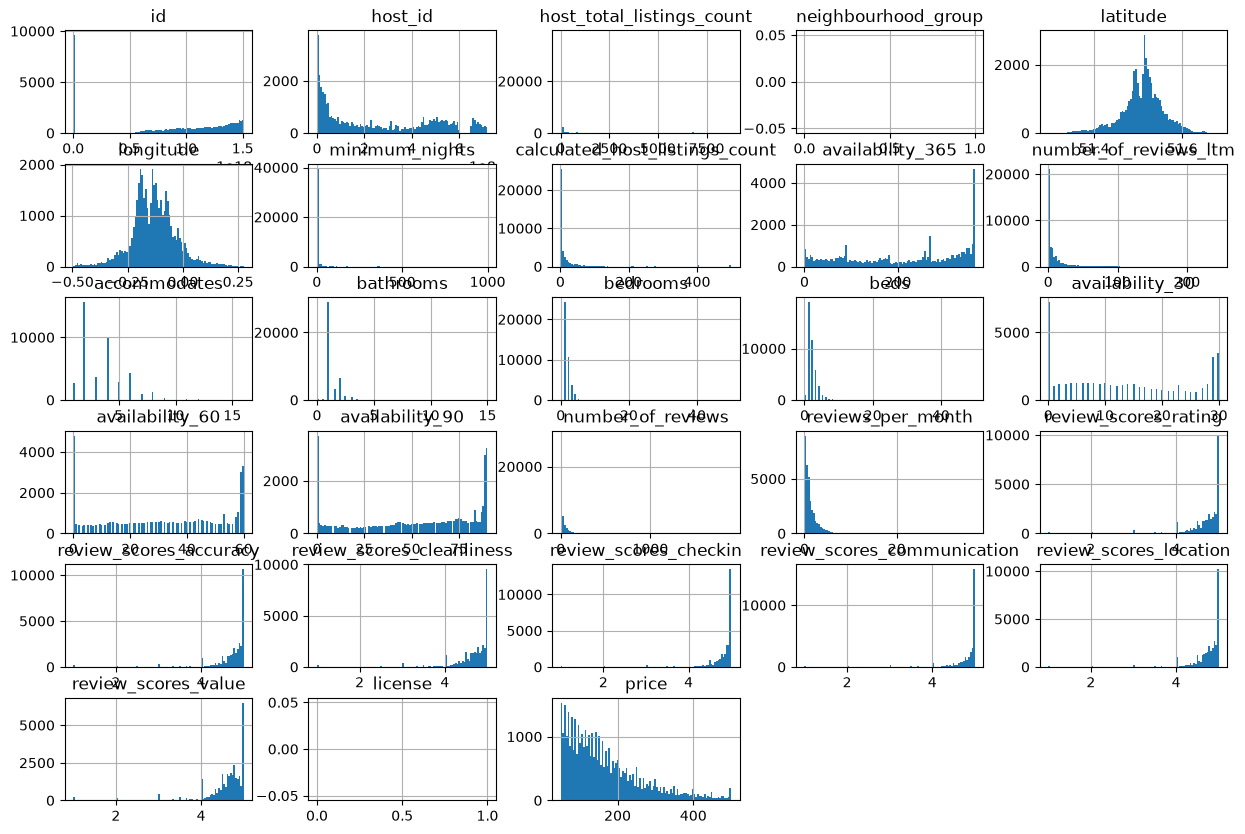

In [1930]:
train_df.hist(bins=100, figsize=(15,10))

In [1931]:
# unique values and their counts
for col in train_df.columns:
    print('--------')
    print(train_df[col].value_counts(dropna=False))

--------
id
863718884129314541     1
1246272787951735423    1
995836785136017274     1
888497692875319566     1
1069328087003020991    1
                      ..
52667545               1
1424101240983641464    1
1328874387841665633    1
2576995                1
750547105050926406     1
Name: count, Length: 42234, dtype: int64
--------
name
Flat in London                                       14
Standard Single Room                                 12
Letzi Ensuite Room | 10 Mins Wembley | Fast WiFi     11
Seven Dials Hotel, Covent Garden, Single en suite    11
Private Double Room in Warren Street                 11
                                                     ..
Lovely bedroom in a large flat                        1
River view 2 bedroom flat                             1
Charming West London Mews House                       1
Dbl Room, W'stow Central 2 mins                       1
Double room @ Hackney, near Victoria Park London      1
Name: count, Length: 41118, dtype: int64
-

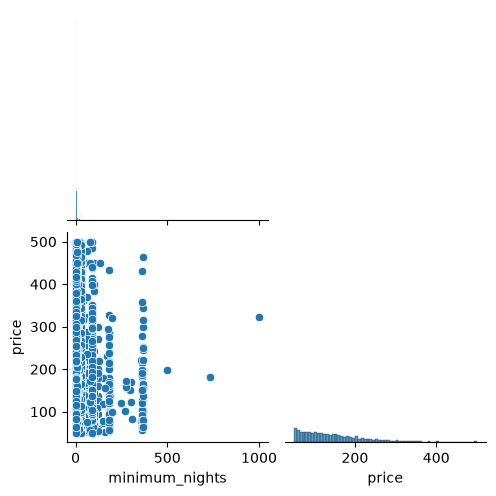

In [1932]:
# is there a correlation between minimum nights and price
import seaborn as sns
sns.pairplot(train_df[['minimum_nights', 'price']], corner=True)

<Axes: xlabel='minimum_nights', ylabel='price'>

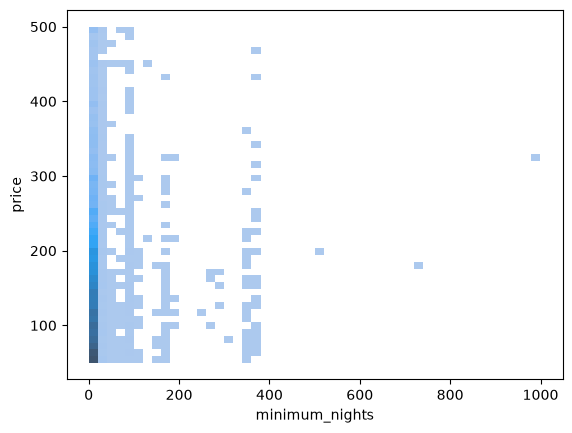

In [1933]:
sns.histplot(bins=50, x=train_df['minimum_nights'], y=train_df['price'])

In [1934]:
train_df['price'].corr(train_df['minimum_nights'])

np.float64(0.032336063826619195)

In [1935]:
train_df.corr(numeric_only=True)['price'].sort_values(key=abs)

review_scores_checkin            -0.002452
latitude                         -0.003684
review_scores_value              -0.004885
host_id                          -0.007391
review_scores_communication      -0.009543
review_scores_accuracy            0.021345
id                                0.023595
availability_90                   0.029260
minimum_nights                    0.032336
review_scores_rating              0.037623
availability_60                   0.046517
review_scores_cleanliness         0.048742
availability_30                   0.050317
longitude                        -0.057776
availability_365                  0.073709
number_of_reviews_ltm            -0.100551
reviews_per_month                -0.102201
number_of_reviews                -0.107712
review_scores_location            0.108153
host_total_listings_count         0.117902
calculated_host_listings_count    0.204432
bathrooms                         0.368218
beds                              0.411513
bedrooms   

# Data Cleansing/ Feature Engineering

In [1936]:
#removing totally null columns and string columns except for neighborhood
train_df.drop(['id', 'name', 'host_name', 'host_id', 'host_has_profile_pic', 'neighbourhood_group', 'last_review', 'review_scores_communication', 'review_scores_value', 'review_scores_checkin', 'license'], axis=1, inplace=True)
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 42234 entries, 0 to 42233
Data columns (total 25 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   host_total_listings_count       42218 non-null  float64
 1   host_identity_verified          42218 non-null  str    
 2   neighbourhood                   42234 non-null  str    
 3   latitude                        42234 non-null  float64
 4   longitude                       42234 non-null  float64
 5   room_type                       42234 non-null  str    
 6   minimum_nights                  42234 non-null  int64  
 7   calculated_host_listings_count  42234 non-null  int64  
 8   availability_365                42234 non-null  int64  
 9   number_of_reviews_ltm           42234 non-null  int64  
 10  accommodates                    42234 non-null  int64  
 11  bathrooms                       42192 non-null  float64
 12  bedrooms                        42187 non-n

In [1937]:
#with the help of claude, took str in amenities (represented as '[amenity one, amenity two, ...]') 
# and treated them as a list to count the number of amenities
import json

def count_amenities(s):
    if pd.isna(s):
        return 0
    return len(json.loads(s))

train_df['num_amenities'] = train_df['amenities'].apply(count_amenities)
test_df['num_amenities'] = test_df['amenities'].apply(count_amenities)

In [1938]:
train_df[['amenities', 'num_amenities']].head()

,amenities,num_amenities
0,"[""Clothing storage: wardrobe"", ""Self check-in""...",55
1,"[""Kitchen"", ""Cleaning products"", ""Smoke alarm""...",39
2,"[""Clothing storage: wardrobe"", ""Safe"", ""HDTV w...",44
3,"[""Essentials"", ""TV"", ""Cleaning products"", ""Fir...",6
4,"[""Self check-in"", ""Kitchen"", ""Smoke alarm"", ""D...",30


In [1939]:
train_df['price'].corr(train_df['num_amenities'])


np.float64(0.20515777991524375)

In [1940]:
train_df.drop(['amenities'], axis=1, inplace=True)
test_df.drop(['amenities'], axis=1, inplace=True)

array([[<Axes: title={'center': 'host_total_listings_count'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'minimum_nights'}>,
        <Axes: title={'center': 'calculated_host_listings_count'}>],
       [<Axes: title={'center': 'availability_365'}>,
        <Axes: title={'center': 'number_of_reviews_ltm'}>,
        <Axes: title={'center': 'accommodates'}>,
        <Axes: title={'center': 'bathrooms'}>,
        <Axes: title={'center': 'bedrooms'}>],
       [<Axes: title={'center': 'beds'}>,
        <Axes: title={'center': 'availability_30'}>,
        <Axes: title={'center': 'availability_60'}>,
        <Axes: title={'center': 'availability_90'}>,
        <Axes: title={'center': 'number_of_reviews'}>],
       [<Axes: title={'center': 'reviews_per_month'}>,
        <Axes: title={'center': 'review_scores_rating'}>,
        <Axes: title={'center': 'review_scores_accuracy'}>,
        <Axes: title={'center': 'rev

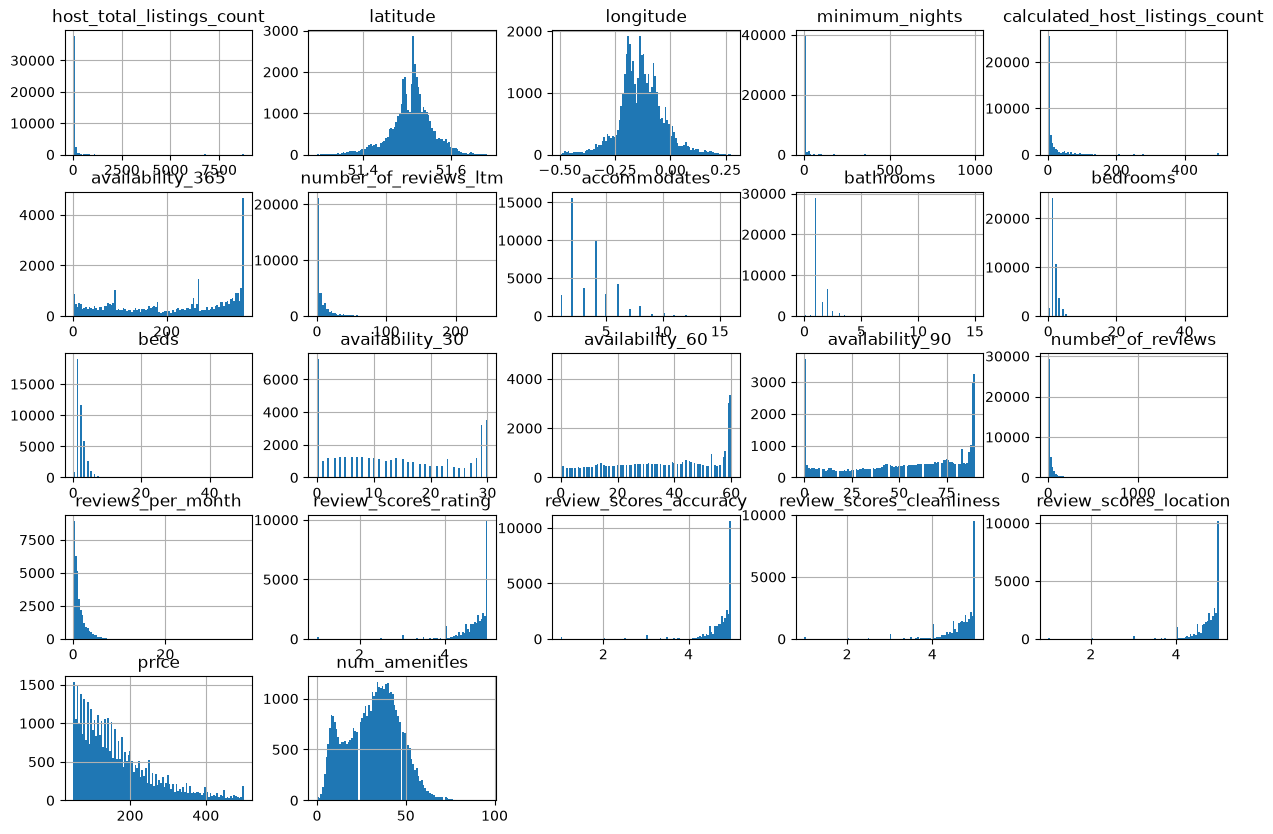

In [1941]:
cols = [c for c in train_df.columns if not c.startswith('neighbourhood_')]
cols = [c for c in cols if not c.startswith('room_type_')]
cols = [c for c in cols if not c.startswith('host_identity_verified_')]
train_df[cols].hist(bins=100, figsize=(15,10))

In [1942]:
#neighborhood has no Nan values
for col in train_df.select_dtypes(include="number").columns:
    train_df[col] = train_df[col].fillna(train_df[col].median())

In [1943]:
#one-hot encoding neighborhood
#Parts taken from Ryan and Matt Datascience YT tutorial on sklearn onehot encoder
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False).set_output(transform='pandas')


In [1944]:
ohetransform = ohe.fit_transform(train_df[['neighbourhood']])
train_df = pd.concat([train_df,ohetransform], axis=1).drop(columns='neighbourhood')

In [1945]:
ohetransform = ohe.fit_transform(train_df[['host_identity_verified']])
ohetransform.info()

<class 'pandas.DataFrame'>
RangeIndex: 42234 entries, 0 to 42233
Data columns (total 3 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   host_identity_verified_f    42234 non-null  float64
 1   host_identity_verified_t    42234 non-null  float64
 2   host_identity_verified_nan  42234 non-null  float64
dtypes: float64(3)
memory usage: 990.0 KB


In [1946]:
train_df = pd.concat([train_df,ohetransform], axis=1).drop(columns='host_identity_verified')

In [1947]:
ohetransform = ohe.fit_transform(train_df[['room_type']])
train_df = pd.concat([train_df,ohetransform], axis=1).drop(columns='room_type')

In [1948]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 42234 entries, 0 to 42233
Data columns (total 62 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   host_total_listings_count             42234 non-null  float64
 1   latitude                              42234 non-null  float64
 2   longitude                             42234 non-null  float64
 3   minimum_nights                        42234 non-null  int64  
 4   calculated_host_listings_count        42234 non-null  int64  
 5   availability_365                      42234 non-null  int64  
 6   number_of_reviews_ltm                 42234 non-null  int64  
 7   accommodates                          42234 non-null  int64  
 8   bathrooms                             42234 non-null  float64
 9   bedrooms                              42234 non-null  float64
 10  beds                                  42234 non-null  float64
 11  availability_30           

In [1949]:
corr_list = train_df.corr(numeric_only=True)['price'].sort_values(key=abs)
print(corr_list.to_string())

neighbourhood_Richmond upon Thames      0.000441
neighbourhood_Hammersmith and Fulham    0.000932
latitude                               -0.003684
neighbourhood_Wandsworth                0.005611
host_identity_verified_nan             -0.007988
room_type_Hotel room                    0.011889
neighbourhood_Islington                -0.016388
host_identity_verified_t               -0.018375
room_type_Shared room                  -0.018625
host_identity_verified_f                0.018974
neighbourhood_Merton                   -0.019420
neighbourhood_Barking and Dagenham     -0.024045
neighbourhood_Newham                   -0.026347
neighbourhood_Kingston upon Thames     -0.026433
neighbourhood_Havering                 -0.027091
neighbourhood_Harrow                   -0.027741
review_scores_accuracy                  0.028019
availability_90                         0.029260
neighbourhood_Lambeth                  -0.030655
neighbourhood_Greenwich                -0.031575
minimum_nights      

In [1950]:
train_df['price'].corr(train_df['host_identity_verified_nan'])

np.float64(-0.007988100890226356)

In [1951]:
train_df.drop(['host_identity_verified_nan'], axis=1, inplace=True)
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 42234 entries, 0 to 42233
Data columns (total 61 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   host_total_listings_count             42234 non-null  float64
 1   latitude                              42234 non-null  float64
 2   longitude                             42234 non-null  float64
 3   minimum_nights                        42234 non-null  int64  
 4   calculated_host_listings_count        42234 non-null  int64  
 5   availability_365                      42234 non-null  int64  
 6   number_of_reviews_ltm                 42234 non-null  int64  
 7   accommodates                          42234 non-null  int64  
 8   bathrooms                             42234 non-null  float64
 9   bedrooms                              42234 non-null  float64
 10  beds                                  42234 non-null  float64
 11  availability_30           

# Model Preparation

In [1952]:
#removing totally null columns and string columns except for neighborhood
test_df.drop(['id', 'name', 'host_name', 'host_id', 'host_has_profile_pic', 'neighbourhood_group', 'last_review', 'review_scores_communication', 'review_scores_value', 'review_scores_checkin', 'license'], axis=1, inplace=True)

In [1953]:
#encoding our test_df the same way we encoded our train_df
ohetransform = ohe.fit_transform(test_df[['neighbourhood']])
test_df = pd.concat([test_df,ohetransform], axis=1).drop(columns='neighbourhood')
ohetransform = ohe.fit_transform(test_df[['host_identity_verified']])
test_df = pd.concat([test_df,ohetransform], axis=1).drop(columns='host_identity_verified')
ohetransform = ohe.fit_transform(test_df[['room_type']])
test_df = pd.concat([test_df,ohetransform], axis=1).drop(columns='room_type')
test_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8199 entries, 0 to 8198
Data columns (total 60 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   host_total_listings_count             8199 non-null   float64
 1   latitude                              8199 non-null   float64
 2   longitude                             8199 non-null   float64
 3   minimum_nights                        8199 non-null   int64  
 4   calculated_host_listings_count        8199 non-null   int64  
 5   availability_365                      8199 non-null   int64  
 6   number_of_reviews_ltm                 8199 non-null   int64  
 7   accommodates                          8199 non-null   int64  
 8   bathrooms                             8199 non-null   float64
 9   bedrooms                              8199 non-null   float64
 10  beds                                  8199 non-null   float64
 11  availability_30             

In [1954]:
from sklearn.model_selection import train_test_split
#taken from our in class practical sep 11
#our Y target(s): airbnb 'price'
#our X or our Data without the Target Data
train_x, test_x, train_y, test_y = train_test_split(train_df.drop(['price'], axis=1, inplace=False), 
                 train_df.price,
                 test_size=0.2)

In [1955]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
ss.fit(train_x)
train_x = ss.transform(train_x)
test_x = ss.transform(test_x)

test_df = ss.transform(test_df)

# Model

In [1956]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()
reg.fit(train_x, train_y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [1957]:
hyp = reg.predict(test_x)
hyp

array([198.47882133, 175.62343889, 234.79083232, ..., 115.67791361,
       205.15311692,  94.05776384], shape=(8447,))

In [1958]:
from sklearn.metrics import mean_squared_error
import numpy as np

np.sqrt(mean_squared_error(test_y, hyp))

np.float64(66.01040760168945)

In [1959]:
predictions = reg.predict(test_df)

In [1960]:
pd.DataFrame(predictions).to_csv('A4_predictions_JoanneHe.csv', index=False)